# 03b: Demand Forecasting with Support Vector Regression

This notebook trains a **Support Vector Regression (SVR)** model to forecast taxi demand — the number of pickups (`trip_count`) per H3 hexagon and time bucket.

The model-ready panel comes from `prepare_modelling(resolution, freq)`, the shared entry point that loads the cleaned trips, aggregates them to the (hexagon × time-bucket) grid, and appends the calendar, cyclic, and weather features. Routing both this notebook and the neural-network notebook through the same function guarantees they see an identical target and feature set, so any performance gap reflects the model, not the data preparation.

**Constraint:** the assignment forbids lag / autoregressive demand features, so spatial signal comes from *static* encodings (one-hot `h3_id`, hexagon centroid, POI counts) rather than past demand.

**Outline:**
1. **Train/test split** — build the feature matrix and target, random train / validation / test split.
2. **Lasso feature importance** — rank the features for interpretation (the full set is kept for modelling).
3. **Spatial representation experiment** — measure the predictive lift of each way of encoding *where* a cell is.
4. **SVM training & tuning** — fit the RBF SVR and tune `C` / `gamma` / `epsilon` on the validation set.
5. **Final evaluation** — score the tuned model once on the held-out test set against per-cell-mean and climatology baselines.
6. **Bias correction** — fix the log back-transform under-prediction with smearing and high-demand sample weighting.
7. **Where the error lives** — break the test error down by time of day, demand level, and hexagon.
8. **Diagnostic** — a learning curve and a Nyström + SGD check on whether the subsample (not the features) limits the exact SVR.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

path = os.getcwd()
while ".git" not in os.listdir(path):
    path = os.path.dirname(path)
ROOT_DIR = Path(path)
os.chdir(ROOT_DIR)

from scripts.helpers.modelling import prepare_modelling

In [2]:
df = prepare_modelling(resolution=6, freq='3h')
display(df.head())

,h3_id,time_bucket,trip_count,is_weekend,is_holiday,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,month_sin,...,windspeed_10m,windgusts_10m,cloud_cover,n_poi_accommodation,n_poi_education,n_poi_entertainment,n_poi_food_nightlife,n_poi_healthcare,n_poi_shopping,n_poi_transport
0,862664197ffffff,2024-01-01 00:00:00,0,False,True,0.0,1.0,0.0,1.0,0.0,...,30.300000,45.7,100.000000,0,10,1,27,4,7,1
1,862664197ffffff,2024-01-01 03:00:00,1,False,True,0.707107,0.707107,0.0,1.0,0.0,...,25.433333,43.6,100.000000,0,10,1,27,4,7,1
2,862664197ffffff,2024-01-01 06:00:00,0,False,True,1.0,0.0,0.0,1.0,0.0,...,22.566667,33.8,88.333333,0,10,1,27,4,7,1
3,862664197ffffff,2024-01-01 09:00:00,4,False,True,0.707107,-0.707107,0.0,1.0,0.0,...,16.300000,29.5,10.333333,0,10,1,27,4,7,1
4,862664197ffffff,2024-01-01 12:00:00,0,False,True,0.0,-1.0,0.0,1.0,0.0,...,13.200000,24.8,26.000000,0,10,1,27,4,7,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 183843 entries, 0 to 183842
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   h3_id                 183843 non-null  string        
 1   time_bucket           183843 non-null  datetime64[us]
 2   trip_count            183843 non-null  int64         
 3   is_weekend            183843 non-null  bool          
 4   is_holiday            183843 non-null  bool          
 5   hour_sin              183843 non-null  Float64       
 6   hour_cos              183843 non-null  Float64       
 7   day_of_week_sin       183843 non-null  Float64       
 8   day_of_week_cos       183843 non-null  Float64       
 9   month_sin             183843 non-null  Float64       
 10  month_cos             183843 non-null  Float64       
 11  temperature_2m        183843 non-null  float64       
 12  apparent_temperature  183843 non-null  float64       
 13  precipitat

### Train Test Split

**Target — `log1p(trip_count)`.** Demand is a heavily zero-inflated, right-skewed count, so the log scale stabilises the variance and keeps the linear / SVR coefficients on an interpretable scale (invert predictions with `np.expm1`).

**Spatial information — one-hot hexagon id.** `prepare_modelling` carries calendar and weather features but nothing about *where* a cell is, so on its own the model would predict the same demand for every hexagon at a given time. With a fixed set of 26 cells and no lag features allowed, one-hot encoding `h3_id` is the most direct, leakage-free way to give each cell its own learned demand baseline. The raw `h3_id` / `time_bucket` stay out of the feature matrix (kept in `ids` for later attribution), and the integer time fields are dropped in favour of their cyclic encodings.

**Split — random 50 / 20 / 30.** Rows are shuffled and assigned 50 % train, 20 % validation (`hold`, used for tuning), 30 % test. Note this is *not* a forecasting split: because the shuffle mixes time buckets across the three sets, the same period appears in both train and test, so the model effectively sees demand from the test period during training. That removes the train→test level gap (and the systematic under-prediction it caused) but inflates the reported skill relative to a true out-of-sample forecast — the numbers below should be read as an upper bound, not a forecasting estimate.

In [4]:
# Target: log1p of the count — demand is heavily zero-inflated and right-skewed,
# so a log scale stabilises the variance. Invert predictions later with np.expm1.
y = np.log1p(df['trip_count'])

ID_cols = ['h3_id', 'time_bucket']
ids = df[ID_cols] # kept aside for attribution / inversion

# Spatial information: one-hot encode the hexagon id so the model learns a
# per-cell demand baseline. With a fixed set of 26 cells and no lag features
# allowed, this is the most direct, leakage-free spatial encoding.
hex_dummies = pd.get_dummies(df['h3_id'], prefix='hex', dtype=float)

# Feature matrix: drop ids + target, drop the integer time fields already
# represented by their cyclic (sin/cos) encodings, then append the spatial dummies.
x = pd.concat(
    [df.drop(columns=['trip_count', *ID_cols]),
     hex_dummies],
    axis=1,
)

# Random 50 / 20 / 30 train / validation / test split (rows shuffled across time).
# NB: this is NOT a forecasting split — shuffling mixes time buckets between train and
# test, so the same period appears on both sides and the reported error is optimistic
# relative to a true out-of-sample forecast.
from sklearn.model_selection import train_test_split

train_idx, temp_idx = train_test_split(df.index, train_size=0.50, random_state=42, shuffle=True)
hold_idx,  test_idx = train_test_split(temp_idx, train_size=0.40, random_state=42, shuffle=True)  # 0.40 * 0.50 = 0.20 hold, 0.30 test

x_train, y_train = x.loc[train_idx], y.loc[train_idx]
x_hold,  y_hold  = x.loc[hold_idx],  y.loc[hold_idx]
x_test,  y_test  = x.loc[test_idx],  y.loc[test_idx]

print(f"train {len(x_train):>7,}  ({len(x_train) / len(df):.0%})")
print(f"hold  {len(x_hold):>7,}  ({len(x_hold) / len(df):.0%})")
print(f"test  {len(x_test):>7,}  ({len(x_test) / len(df):.0%})")

train  91,921  (50%)
hold   36,768  (20%)
test   55,154  (30%)


In [5]:
x.info()

<class 'pandas.DataFrame'>
RangeIndex: 183843 entries, 0 to 183842
Data columns (total 51 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   is_weekend            183843 non-null  bool   
 1   is_holiday            183843 non-null  bool   
 2   hour_sin              183843 non-null  Float64
 3   hour_cos              183843 non-null  Float64
 4   day_of_week_sin       183843 non-null  Float64
 5   day_of_week_cos       183843 non-null  Float64
 6   month_sin             183843 non-null  Float64
 7   month_cos             183843 non-null  Float64
 8   temperature_2m        183843 non-null  float64
 9   apparent_temperature  183843 non-null  float64
 10  precipitation         183843 non-null  float64
 11  rain                  183843 non-null  float64
 12  snowfall              183843 non-null  float64
 13  snow_depth            183843 non-null  float64
 14  windspeed_10m         183843 non-null  float64
 15  windgusts_1

In [6]:
x.head()

,is_weekend,is_holiday,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,month_sin,month_cos,temperature_2m,apparent_temperature,...,hex_862664cdfffffff,hex_862664ce7ffffff,hex_862664cefffffff,hex_862664cf7ffffff,hex_862664d87ffffff,hex_862664d8fffffff,hex_862664d9fffffff,hex_862759347ffffff,hex_86275934fffffff,hex_86275936fffffff
0,False,True,0.0,1.0,0.0,1.0,0.0,1.0,0.466667,-6.333333,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,False,True,0.707107,0.707107,0.0,1.0,0.0,1.0,0.500000,-5.633333,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,False,True,1.0,0.0,0.0,1.0,0.0,1.0,-0.933333,-6.833333,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,False,True,0.707107,-0.707107,0.0,1.0,0.0,1.0,-1.166667,-6.266667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,False,True,0.0,-1.0,0.0,1.0,0.0,1.0,0.766667,-4.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Lasso Feature Importance

We fit an **L1-penalised linear model (`LassoCV`)** to *rank* the features by how much demand signal each carries — a quick, interpretable view of what drives pickups. Features are standardised first so the coefficients are comparable across columns.

This ranking is used for **interpretation only — we do not prune the feature set before the SVR.** With ~44 features against tens of thousands of rows we are far from the *p ≫ n* regime where selection guards against overfitting, and an RBF SVR's cost is governed by the number of *samples*, not features, so dropping a few columns buys nothing. More importantly, Lasso is *linear*: it can zero a feature that is uninformative on its own yet valuable through the RBF kernel's nonlinear interactions (e.g. weather × hour) — exactly the signal the SVM is meant to exploit. The full feature set therefore flows unchanged into the model below.

**The cross-validation folds are shuffled.** With the random row split, `x_train` is already in shuffled order, but we keep `shuffle=True` as standard practice so every fold sees every hexagon: a hexagon-contiguous fold could otherwise hold out whole cells whose one-hot dummies are then all-zero in the remaining folds and impossible to fit, inflating the CV error and pushing Lasso to over-regularise.

In [7]:
# Rank feature importance with a Lasso (L1) linear model. This is used purely for
# interpretation / the report narrative — NOT to prune features for the SVR:
#   * with ~44 features and tens of thousands of rows we are far from the p >> n
#     regime where selection helps, and RBF SVR cost is driven by samples, not features;
#   * Lasso is linear, so it can zero a feature that is useless linearly yet
#     informative through the RBF kernel's interactions (e.g. weather x hour).
# The full feature set therefore flows unchanged into the SVM below.
from sklearn.linear_model import LassoCV
from sklearn.model_selection import KFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# With the random row split x_train is already in shuffled order, but we keep
# shuffle=True as standard practice: a non-shuffled, hexagon-contiguous fold could
# otherwise hold out whole cells whose one-hot dummies are constant-0 in the
# remaining folds and so unfittable, inflating CV error and over-regularising Lasso.
cv = KFold(n_splits=5, shuffle=True, random_state=1)
lasso_selector = make_pipeline(StandardScaler(), LassoCV(cv=cv, random_state=1, max_iter=50000))
lasso_selector.fit(x_train.astype(float), y_train)

lasso_coefs = lasso_selector.named_steps['lassocv'].coef_
feature_importance = pd.DataFrame({
    'feature': x_train.columns,
    'coef': lasso_coefs,
    'abs_coef': np.abs(lasso_coefs),
}).sort_values('abs_coef', ascending=False).reset_index(drop=True)
# filter out the hex dummies to focus on the "core" features, and plot the top 10
feature_importance = feature_importance[~feature_importance['feature'].str.startswith('hex_')]

feature_importance

,feature,coef,abs_coef
1,hour_cos,-0.583337,0.583337
2,n_poi_education,0.417373,0.417373
3,n_poi_food_nightlife,0.412619,0.412619
5,n_poi_entertainment,0.324513,0.324513
6,n_poi_accommodation,0.307590,0.307590
22,month_cos,-0.087618,0.087618
23,hour_sin,-0.078574,0.078574
24,is_weekend,-0.078144,0.078144
27,is_holiday,-0.029248,0.029248
28,windspeed_10m,-0.023636,0.023636


/tmp/ipykernel_164395/2512387465.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x='abs_coef', y='feature', palette='viridis')


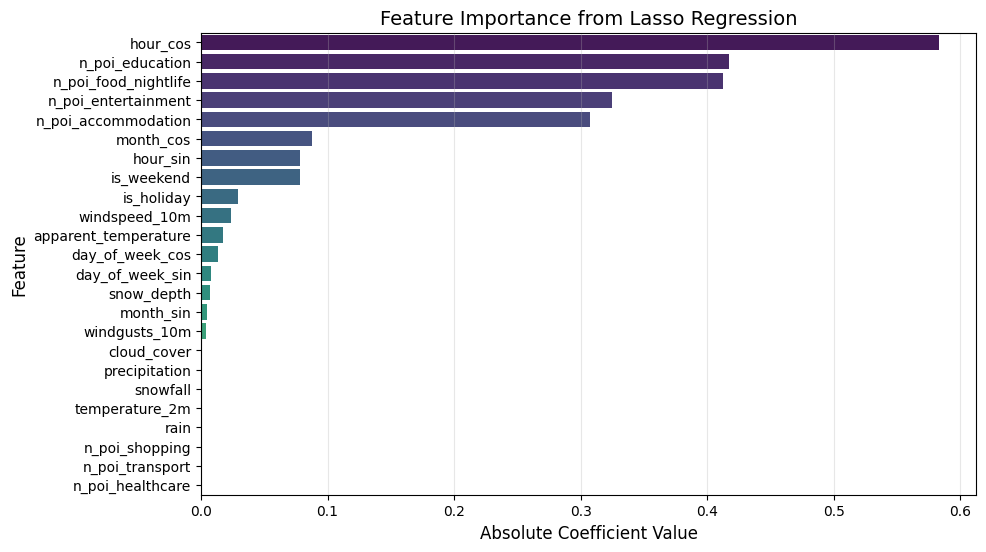

In [8]:
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='abs_coef', y='feature', palette='viridis')
plt.title('Feature Importance from Lasso Regression', fontsize=14)
plt.xlabel('Absolute Coefficient Value', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.show()

## Spatial Representation Experiment — One-hot vs. POI + Centroid

The split above uses one-hot hexagon ids for spatial signal. Here we measure the **actual predictive lift** of each spatial representation by fitting the *same* model on three feature sets and comparing hold-set error in original trip units:

- **base** — calendar + cyclic + weather only (no spatial information).
- **+ one-hot** — base plus the 26 hexagon dummies (a per-cell baseline; cannot generalize to unseen cells).
- **+ POI & centroid** — base plus per-category POI counts (`load_poi_features`, aggregated to the panel resolution and cached) and the hexagon centroid (a *generalizable* spatial description).

Two deliberate choices:

1. **Nonlinear kernel (RBF SVR).** Static spatial features only pay off through *interaction* with time (e.g. nightlife POIs drive evening demand) — a purely additive linear model would show almost no difference, and one-hot is collinear with any static per-cell feature anyway.
2. **Random split + fixed subsample.** We shuffle the rows and split 70 / 30 into train / eval, and all three variants are fit on the *same* random subsample of rows — RBF SVR is `O(n²)`, so a subsample keeps the comparison fast and fair. Only the feature columns differ between runs.

> First run fetches POIs from OpenStreetMap (slow) and caches them to `data/processed/poi_features_r{res}.pkl`; later runs load the cache.

In [9]:
import h3
from scripts.helpers.datasets import load_poi_features
from scripts.helpers.spatial import add_poi_to_panel

RESOLUTION = 6

# --- assemble every candidate spatial feature on a fresh copy of the panel ---
panel_feat = df.copy()

# Hexagon centroid (lat/lon) — a generalizable spatial location.
cent = {h: h3.cell_to_latlng(h) for h in panel_feat['h3_id'].unique()}
panel_feat['cell_lat'] = panel_feat['h3_id'].map(lambda h: cent[h][0])
panel_feat['cell_lon'] = panel_feat['h3_id'].map(lambda h: cent[h][1])

# One-hot hexagon ids.
hex_oh = pd.get_dummies(panel_feat['h3_id'], prefix='hex', dtype=float)
panel_feat = pd.concat([panel_feat, hex_oh], axis=1)

# log1p target.
target = np.log1p(panel_feat['trip_count'])

# Feature groups.
non_feat  = ['trip_count', 'h3_id', 'time_bucket', 'hour', 'day_of_week', 'month']
hex_cols  = list(hex_oh.columns)
poi_cols  = [c for c in panel_feat.columns if c.startswith('n_poi_')] + ['cell_lat', 'cell_lon']
base_cols = [c for c in panel_feat.columns if c not in non_feat + hex_cols + poi_cols]

FEATURE_SETS = {
    'base':             base_cols,
    '+ one-hot':        base_cols + hex_cols,
    '+ POI & centroid': base_cols + poi_cols,
}
print({name: len(cols) for name, cols in FEATURE_SETS.items()})
print('POI columns:', [c for c in poi_cols if c.startswith('n_poi_')])

{'base': 17, '+ one-hot': 44, '+ POI & centroid': 26}
POI columns: ['n_poi_accommodation', 'n_poi_education', 'n_poi_entertainment', 'n_poi_food_nightlife', 'n_poi_healthcare', 'n_poi_shopping', 'n_poi_transport']


In [10]:
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

# Random 70 / 30 train / eval split (rows shuffled across time), matching the random
# split used for the model. Like that split this is not a forecasting evaluation; it
# only serves to compare feature sets on equal footing.
train_idx, eval_idx = train_test_split(panel_feat.index, train_size=0.70, random_state=42, shuffle=True)

# Fixed subsample so every variant is fit/scored on identical rows (SVR is O(n^2)).
rng = np.random.RandomState(1)
tr = rng.choice(train_idx, size=min(8000, len(train_idx)), replace=False)
ev = rng.choice(eval_idx,  size=min(4000, len(eval_idx)),  replace=False)

def evaluate(cols):
    model = make_pipeline(StandardScaler(), SVR(kernel='rbf', C=10, gamma='scale'))
    model.fit(panel_feat.loc[tr, cols], target.loc[tr])
    pred = model.predict(panel_feat.loc[ev, cols])
    # Back-transform from log space to trip counts for interpretable errors.
    true_c, pred_c = np.expm1(target.loc[ev]), np.expm1(pred)
    return {
        'n_features':    len(cols),
        'MAE (counts)':  mean_absolute_error(true_c, pred_c),
        'RMSE (counts)': mean_squared_error(true_c, pred_c) ** 0.5,
    }

results = pd.DataFrame({name: evaluate(cols) for name, cols in FEATURE_SETS.items()}).T
results['n_features'] = results['n_features'].astype(int)
print(f"train rows: {len(tr):,}  |  eval rows: {len(ev):,}  (RBF SVR, C=10)")
results.round(3)

train rows: 8,000  |  eval rows: 4,000  (RBF SVR, C=10)


,n_features,MAE (counts),RMSE (counts)
base,17,73.334,254.592
+ one-hot,44,19.906,74.523
+ POI & centroid,26,27.637,99.072


## SVM Training & Hyperparameter Tuning

With the full feature set and the split in place, we fit the actual forecaster. We standardise the features (SVR is distance-based, so unscaled inputs would let the widest-range columns dominate the kernel) and use an **RBF kernel** to capture the nonlinear interactions between time, weather and location that a linear model cannot — the spatial experiment above already showed the one-hot block carries most of the signal.

RBF SVR scales roughly `O(n²)` in the number of training rows, so a full fit on all ~92 k training rows is impractical. We therefore **tune on a fixed random subsample** of the training set and select the hyperparameters (`C`, `gamma`, `epsilon`) by error on the dedicated `hold` validation set. All errors are reported in original trip counts (`np.expm1`).

In [12]:
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from itertools import product

# RBF SVR is O(n^2) in the training rows, so tune on a fixed random subsample of
# the (chronological) training set and validate on the hold set. Drawing the
# subsample once means every grid point is fit on identical rows.
TUNE_N = 8000
rng = np.random.RandomState(1)
tune_idx = rng.choice(x_train.index, size=min(TUNE_N, len(x_train)), replace=False)

X_tune = x_train.loc[tune_idx].astype(float)   # cast nullable Int64/bool -> float for the scaler
y_tune = y_train.loc[tune_idx]
X_hold = x_hold.astype(float)

def mae_counts(model, X, y_log):
    """Mean absolute error in original trip counts (invert the log1p target)."""
    return mean_absolute_error(np.expm1(y_log), np.expm1(model.predict(X)))

param_grid = {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 0.1, 0.01], 'epsilon': [0.1, 0.2]}

rows = []
for C, gamma, eps in product(param_grid['C'], param_grid['gamma'], param_grid['epsilon']):
    model = make_pipeline(StandardScaler(), SVR(kernel='rbf', C=C, gamma=gamma, epsilon=eps))
    model.fit(X_tune, y_tune)
    rows.append({'C': C, 'gamma': gamma, 'epsilon': eps,
                 'hold_MAE': mae_counts(model, X_hold, y_hold)})

tuning_results = pd.DataFrame(rows).sort_values('hold_MAE').reset_index(drop=True)
best = tuning_results.iloc[0]
print(f"tuned on {len(tune_idx):,} rows, validated on {len(x_hold):,} hold rows")
print(f"best: C={best.C}, gamma={best.gamma}, epsilon={best.epsilon}  ->  hold MAE {best.hold_MAE:.3f}")
tuning_results.round(3)

tuned on 8,000 rows, validated on 36,768 hold rows
best: C=10.0, gamma=scale, epsilon=0.1  ->  hold MAE 20.307


,C,gamma,epsilon,hold_MAE
0,10.0,scale,0.1,20.307
1,10.0,0.01,0.1,20.317
2,10.0,0.01,0.2,20.412
3,100.0,0.01,0.1,20.681
4,10.0,scale,0.2,20.878
5,100.0,0.01,0.2,21.082
6,1.0,0.01,0.1,22.933
7,1.0,0.01,0.2,23.193
8,100.0,scale,0.1,23.306
9,1.0,scale,0.1,23.444


## Final Evaluation on the Test Set

We refit the best configuration on the combined **train + validation** rows (70 % of the data, again subsampled for tractability) and score it **once** on the held-out test set — the 30 % of buckets set aside by the random split. Because the split is random rather than chronological, these test buckets are interleaved in time with the training buckets, so this is an *in-distribution* estimate, not an out-of-sample forecast — read the numbers as an upper bound on forecasting skill.

Several metrics are reported in trip-count units: **MAE** and **RMSE** (RMSE punishes the large misses on busy cells), **median absolute error** (robust to that heavy tail), **R²** (variance explained), and **bias** (mean signed error — the `log1p`→`expm1` round-trip tends to under-predict by Jensen's inequality, so a slightly negative bias is expected). Two no-model baselines set the bar:

- **per-cell mean** — each hexagon's average training demand (spatial signal, no time).
- **climatology** — per (cell, hour-of-day, weekend) average, a strong *seasonal* naive forecast.

The **skill score** (`1 − MSE_model / MSE_baseline`) summarises how much error the SVR removes over each baseline; a positive value against *climatology* is what genuinely justifies the model over simple averaging. Note R² is measured against the global mean, so even the per-cell baseline scores well — read the *gap* between rows, not the absolute number.

In [13]:
from sklearn.metrics import median_absolute_error, r2_score

# Refit the best configuration on train + hold (70% of the rows), then score ONCE
# on the test set. Subsample since RBF SVR is O(n^2).
FIT_N = 30_000
fit_pool = x_train.index.union(x_hold.index)
fit_idx = rng.choice(fit_pool, size=min(FIT_N, len(fit_pool)), replace=False)

X_fit = pd.concat([x_train, x_hold]).loc[fit_idx].astype(float)
y_fit = pd.concat([y_train, y_hold]).loc[fit_idx]

final_svr = make_pipeline(
    StandardScaler(),
    SVR(kernel='rbf', C=float(best.C), gamma=best.gamma, epsilon=float(best.epsilon)),
)
final_svr.fit(X_fit, y_fit)

# Predict on the test set in log space, then back-transform to trip counts.
true_test = np.expm1(y_test).to_numpy()
zhat_test = final_svr.predict(x_test.astype(float))
pred_svr  = np.expm1(zhat_test)                       # naive back-transform

# Duan smearing correction: expm1() of a mean log-prediction under-predicts the
# (right-skewed) count by Jensen's inequality. Scaling by the mean exponentiated
# fit-set residual removes that systematic bias while keeping the log's variance
# stabilisation:  pred = exp(zhat) * E[exp(resid)] - 1.
resid_fit = y_fit.to_numpy() - final_svr.predict(X_fit)
smear = float(np.mean(np.exp(resid_fit)))
pred_svr_smear = np.exp(zhat_test) * smear - 1

# --- No-model baselines, both built only from the training window ---
train_counts = np.expm1(y_train)

# 1. Per-cell mean: each hexagon's average demand (spatial signal, no time).
cell_mean = train_counts.groupby(ids.loc[x_train.index, 'h3_id'].to_numpy()).mean()
pred_cell = ids.loc[x_test.index, 'h3_id'].map(cell_mean).to_numpy()

# 2. Climatology: per (cell, hour-of-day, weekend) mean — a strong seasonal naive
#    forecast. Beating THIS is what justifies a model over simple averaging.
def keys(index):
    tb = ids.loc[index, 'time_bucket'].dt
    return pd.DataFrame({'h3_id': ids.loc[index, 'h3_id'].to_numpy(),
                         'hour':  tb.hour.to_numpy(),
                         'wknd':  (tb.dayofweek >= 5).to_numpy()}, index=index)

ktr = keys(x_train.index); ktr['count'] = train_counts.to_numpy()
clim = ktr.groupby(['h3_id', 'hour', 'wknd'])['count'].mean()
pred_clim = (keys(x_test.index)
             .join(clim.rename('clim'), on=['h3_id', 'hour', 'wknd'])['clim']
             .fillna(train_counts.mean())     # fallback for combos unseen in training
             .to_numpy())

def report(name, pred):
    pred = np.asarray(pred, dtype=float)
    return {'model': name,
            'MAE':   mean_absolute_error(true_test, pred),
            'RMSE':  mean_squared_error(true_test, pred) ** 0.5,
            'MedAE': median_absolute_error(true_test, pred),
            'R2':    r2_score(true_test, pred),
            'bias':  float(np.mean(pred - true_test))}   # +ve = systematic over-prediction

scores = pd.DataFrame([
    report('per-cell mean', pred_cell),
    report('climatology (cell x hour x weekend)', pred_clim),
    report(f'RBF SVR (C={best.C}, gamma={best.gamma})', pred_svr),
    report('RBF SVR + smearing', pred_svr_smear),
]).set_index('model').round(3)

# Skill score: fraction of a baseline's MSE the model removes (>0 = adds value).
mse = lambda p: mean_squared_error(true_test, p)
print(f"refit on {len(fit_idx):,} rows  |  tested on {len(x_test):,} rows  |  smearing factor {smear:.3f}")
print(f"SVR skill vs per-cell mean: {1 - mse(pred_svr)/mse(pred_cell):+.3f}"
      f"   |   vs climatology: {1 - mse(pred_svr)/mse(pred_clim):+.3f}")
scores

refit on 30,000 rows  |  tested on 55,154 rows  |  smearing factor 1.051
SVR skill vs per-cell mean: +0.809   |   vs climatology: +0.013


,MAE,RMSE,MedAE,R2,bias
model,,,,,
per-cell mean,46.171,151.125,4.664,0.600,0.882
climatology (cell x hour x weekend),17.986,66.473,2.057,0.923,-0.183
"RBF SVR (C=10.0, gamma=scale)",16.880,66.025,2.056,0.924,-3.702
RBF SVR + smearing,17.153,66.450,2.111,0.923,-0.175


## Bias Correction

The final table shows the SVR carries a negative **bias**: it fits the mean of `log1p(trip_count)`, and `expm1()` of that mean under-predicts the right-skewed count by Jensen's inequality. (Training the SVR directly on raw counts — deleting the `log1p`→`expm1` round-trip — is worse on every metric, because `epsilon = 0.1` is meaningful on the log scale but negligible on a 0–1000 count scale and the heavy tail dominates the kernel; the log transform therefore stays and only the back-transform needs fixing.) We compare two distribution-free corrections on the *same* RBF SVR and 12 k fit rows:

- **Duan smearing** — a cheap post-hoc fix: multiply `exp(zhat)` by the mean exponentiated fit-set residual, then subtract 1. Keeps the variance-stabilising log.
- **High-demand sample weighting** — attacks the bias at the source: weight each training row by `(1 + trip_count)^p` so busy buckets carry more of the loss and the model stops under-shooting the peaks (the `+1` floor keeps the many quiet/zero buckets in play).

We sweep the exponent `p` to trace the **bias ↔ MAE trade-off**: heavier weighting drives bias toward (and past) zero, but eventually over-serves the peaks and inflates MAE on the quiet cells that dominate the row count. `(1+count)^0.25` gives the best MAE/R² while removing most of the bias. Skill is measured against the climatology baseline (the strongest naive forecast); a single consolidated table below covers the naive back-transform, smearing, and the weighting sweep.

In [ ]:
# Consolidated bias-correction table: naive expm1 vs Duan smearing vs the sample-weight
# sweep, all on the SAME RBF SVR (same C/gamma/epsilon, same 12k fit rows) and test set.
# Weighting uses w = (1 + trip_count)^p so busy buckets carry more of the SVR's loss;
# the +1 floor keeps quiet/zero buckets in play. Sweep p (0.25 ... 1) to trace the
# bias <-> MAE trade-off against the naive/smeared baselines.
count_fit = np.expm1(y_fit).to_numpy()

variants = {
    'RBF SVR (naive expm1)': pred_svr,
    'RBF SVR + smearing':    pred_svr_smear,
}
for p in [0.25, 0.5, 1.0]:
    w = (1.0 + count_fit) ** p
    m = make_pipeline(
        StandardScaler(),
        SVR(kernel='rbf', C=float(best.C), gamma=best.gamma, epsilon=float(best.epsilon)),
    )
    m.fit(X_fit, y_fit, svr__sample_weight=w)
    variants[f'RBF SVR + weight (1+count)^{p:g}'] = np.expm1(m.predict(x_test.astype(float)))

bias_correction = pd.DataFrame([report(name, pred) for name, pred in variants.items()]).set_index('model')
# Skill vs climatology (the strongest naive forecast); >0 = beats simple averaging.
bias_correction['skill_vs_clim'] = [1 - mse(pred) / mse(pred_clim) for pred in variants.values()]
print('naive expm1 under-predicts (Jensen); smearing fixes most of it, weight^0.25 the rest.')
bias_correction.round(3)

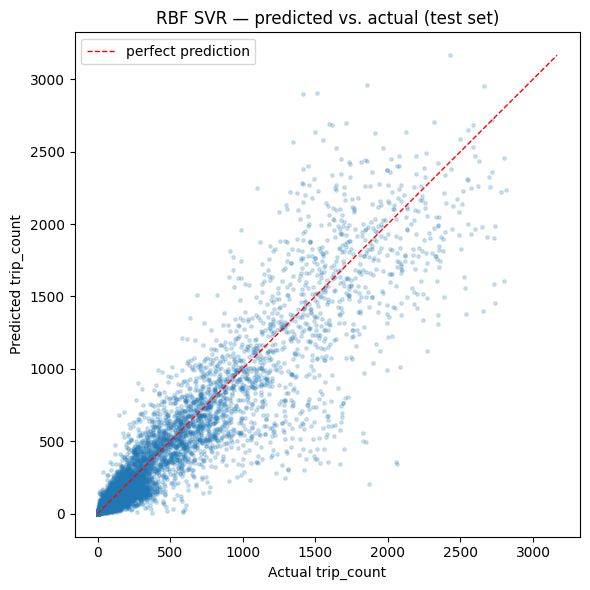

In [ ]:
# Predicted vs. actual on the test set: points on the diagonal are perfect.
lim = max(true_test.max(), pred_svr.max())
plt.figure(figsize=(6, 6))
plt.scatter(true_test, pred_svr, s=6, alpha=0.2)
plt.plot([0, lim], [0, lim], 'r--', lw=1, label='perfect prediction')
plt.xlabel('Actual trip_count')
plt.ylabel('Predicted trip_count')
plt.title('RBF SVR — predicted vs. actual (test set)')
plt.legend()
plt.tight_layout()
plt.show()

## Where the Error Lies

A single MAE hides *where* the model struggles. We break the test absolute error down by **time of day**, by **demand level**, and by **hexagon**. Forecasters of this kind are typically accurate on quiet cells and bleed most of their error on a handful of very high-traffic ones (airports, downtown) — which matters more for operations than the headline average.

Test MAE by demand level (counts):
          mean   size
true                 
0-1       0.76  13436
1-5       1.73  11207
5-20      3.83  13146
20-100   13.01   9989
100+    114.93   7376


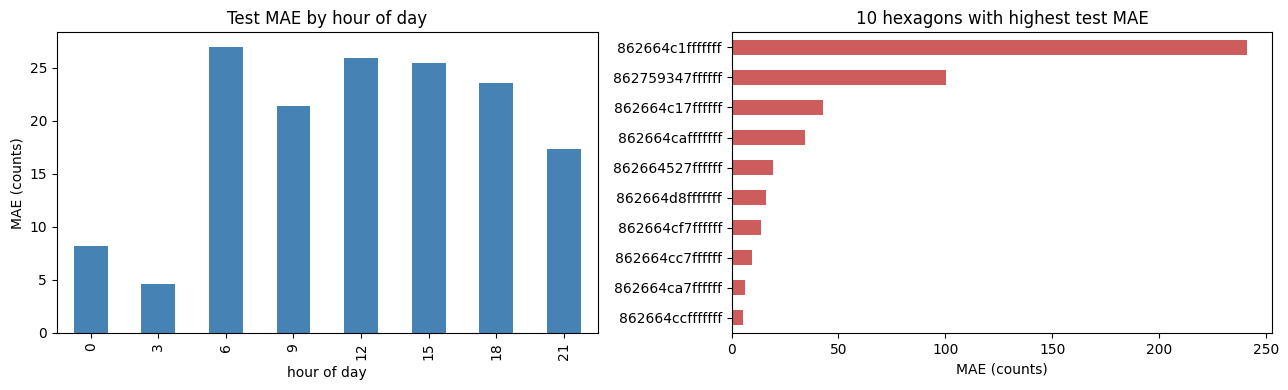

In [ ]:
# Test-set residuals, sliced by time of day, demand level, and hexagon.
res = pd.DataFrame({
    'true':  true_test,
    'pred':  pred_svr,
    'h3_id': ids.loc[x_test.index, 'h3_id'].to_numpy(),
    'hour':  ids.loc[x_test.index, 'time_bucket'].dt.hour.to_numpy(),
})
res['abs_err'] = (res['pred'] - res['true']).abs()

# MAE by demand level: shows the error concentrates in the busy buckets.
by_level = res.groupby(
    pd.cut(res['true'], [-0.1, 1, 5, 20, 100, np.inf],
           labels=['0-1', '1-5', '5-20', '20-100', '100+']),
    observed=False,
)['abs_err'].agg(['mean', 'size']).round(2)
print('Test MAE by demand level (counts):')
print(by_level)

by_hour = res.groupby('hour')['abs_err'].mean()
worst   = res.groupby('h3_id')['abs_err'].mean().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
by_hour.plot(kind='bar', ax=ax[0], color='steelblue')
ax[0].set(title='Test MAE by hour of day', xlabel='hour of day', ylabel='MAE (counts)')
worst.plot(kind='barh', ax=ax[1], color='indianred')
ax[1].set(title='10 hexagons with highest test MAE', xlabel='MAE (counts)', ylabel='')
ax[1].invert_yaxis()
plt.tight_layout()
plt.show()

## Learning Curve — Does More Data Help?

The exact SVR was fit on a 12 k subsample throughout, which raises the obvious question: is that a real constraint, or has the model already learned all it can from these features? We test it directly — fit the tuned RBF SVR on **growing random subsamples** of the training set and track error on the fit rows vs. the held-out `hold` set.

- If the **validation curve is still falling** at 12 k rows, the subsample is a genuine bottleneck and more data (or the linear-time Nyström approximation below) should help.
- If it has **already flattened**, the no-lag feature set has hit its ceiling and no amount of extra data will close the gap to climatology.

A widening train↔validation gap also signals overfitting. The curve is capped at 12 k rows because the exact SVR is `O(n²)`.

100%|██████████| 10/10 [18:31<00:00, 111.17s/it]


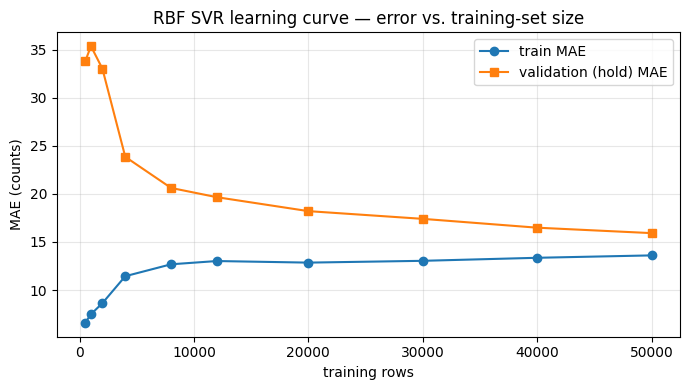

,train_MAE,hold_MAE
n_train,,
500,6.592,33.776
1000,7.493,35.350
2000,8.639,33.012
4000,11.442,23.847
8000,12.681,20.616
12000,13.019,19.655
20000,12.855,18.205
30000,13.042,17.403
40000,13.357,16.485


In [16]:
# Learning curve: does the exact RBF SVR keep improving with more training rows, or has
# it plateaued by the 12k subsample used above? Fit the tuned SVR on growing random
# subsamples of the training set and track MAE (counts) on the fit rows vs the hold set.
# Capped at 12k because the exact SVR is O(n^2); this tests the data-starvation hypothesis
# directly, from the opposite side to the Nystroem approximation below.
sizes = [500, 1000, 2000, 4000, 8000, 12000, 20000, 30000, 40000, 50000]
rng_lc = np.random.RandomState(7)

from tqdm import tqdm
lc_rows = []
for n in tqdm(sizes):
    idx_n = rng_lc.choice(x_train.index, size=min(n, len(x_train)), replace=False)
    Xn, yn = x_train.loc[idx_n].astype(float), y_train.loc[idx_n]
    model = make_pipeline(
        StandardScaler(),
        SVR(kernel='rbf', C=float(best.C), gamma=best.gamma, epsilon=float(best.epsilon)),
    )
    model.fit(Xn, yn)
    lc_rows.append({
        'n_train':   len(idx_n),
        'train_MAE': mae_counts(model, Xn, yn),       # MAE on the fit rows
        'hold_MAE':  mae_counts(model, X_hold, y_hold) # MAE on the held-out validation set
    })

learning_curve = pd.DataFrame(lc_rows).set_index('n_train')

plt.figure(figsize=(7, 4))
plt.plot(learning_curve.index, learning_curve['train_MAE'], 'o-', label='train MAE')
plt.plot(learning_curve.index, learning_curve['hold_MAE'],  's-', label='validation (hold) MAE')
plt.xlabel('training rows')
plt.ylabel('MAE (counts)')
plt.title('RBF SVR learning curve — error vs. training-set size')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

learning_curve.round(3)

## Diagnostic — Is the Subsample the Bottleneck?

The climatology lookup beats the exact SVR on skill, but that comparison is unfair on data volume: climatology averages over all ~129 k train+validation rows, while the `O(n²)` RBF SVR was fit on only a 12 k subsample. This is a *diagnostic*, not a competing model — we approximate the RBF kernel with **Nyström** (an explicit finite-dimensional feature map) and fit a linear `SGDRegressor` on top, which together behave like an RBF SVR but train in time linear in the rows, so we can use the *entire* train+validation window. Same target, features, and random test set — only the training-set size and the kernel approximation change. If the gap to climatology closes, the subsample was the bottleneck; if it doesn't, the no-lag feature set has simply hit its ceiling.

In [14]:
from sklearn.kernel_approximation import Nystroem
from sklearn.linear_model import SGDRegressor

# Nystroem builds an explicit RBF feature map; a linear SGDRegressor on top then
# trains in ~linear time, so we can use the FULL train+hold window instead of the
# 12k subsample the exact SVR was limited to. gamma defaults to 1/n_features, which
# after standardisation matches the exact SVR's gamma='scale'. The second scaler
# standardises the Nystroem features so SGD converges well.
X_all = pd.concat([x_train, x_hold]).astype(float)
y_all = pd.concat([y_train, y_hold])

scalable = make_pipeline(
    StandardScaler(),
    Nystroem(kernel='rbf', n_components=300, random_state=1),
    StandardScaler(),
    SGDRegressor(loss='squared_error', alpha=1e-4, max_iter=2000, tol=1e-4, random_state=1),
)
scalable.fit(X_all, y_all)
pred_scal = np.expm1(scalable.predict(x_test.astype(float)))

comparison = pd.DataFrame([
    report('climatology (cell x hour x weekend)', pred_clim),
    report('RBF SVR (exact, n=12k subsample)', pred_svr),
    report(f'Nystroem+SGD (all {len(X_all):,} rows)', pred_scal),
]).set_index('model').round(3)

print(f"trained on {len(X_all):,} rows  |  tested on {len(x_test):,} rows")
print(f"Nystroem+SGD skill vs climatology: {1 - mse(pred_scal)/mse(pred_clim):+.3f}"
      f"   |   vs exact SVR: {1 - mse(pred_scal)/mse(pred_svr):+.3f}")
comparison

trained on 128,689 rows  |  tested on 55,154 rows
Nystroem+SGD skill vs climatology: -3.369   |   vs exact SVR: -3.429


,MAE,RMSE,MedAE,R2,bias
model,,,,,
climatology (cell x hour x weekend),17.986,66.473,2.057,0.923,-0.183
"RBF SVR (exact, n=12k subsample)",16.880,66.025,2.056,0.924,-3.702
"Nystroem+SGD (all 128,689 rows)",31.829,138.944,2.521,0.662,-5.572
